# G배수지에서 나가는 물 예측
**근데 이제 기상 데이터를 곁들인...**
- (Github에서 받을 경우) csv 파일들은 루트 디렉터리에!

In [65]:
import numpy as np
import torch
import torch.nn as nn  
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [66]:
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
import scipy
print(f"scipy: {scipy.__version__}")
print(f"torch: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

numpy: 1.26.4
pandas: 2.1.4
scipy: 1.12.0
torch: 2.2.0+cu121
Using device: cuda


**Params**

In [67]:
#data slicing
start = 1440 * 0 # +1일차
if (start != 0):
    start = start-2
end = start- 1 + 1439 * 365 #일간
split_rate = 1 - 1/4 

#Sliding window config
window_size=180
forecast_size=15
lead_time=10 #forecast_size 보다 커지면 윈도우 사이에 갭이 생기므로 주의

#LSTM config
units = 64

#learning config
epochs=10
batch_size=64
lr=0.0001718750157412344 # < 0.08
dropout=0.5944708972513388

**배수지 데이터 로드 및 처리**

In [68]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

In [69]:
g_resv_flow_temp = g_resv_flow[start:end].copy()

time = pd.to_datetime(g_resv_flow_temp['time'])
g_resv_flow_temp.loc[:,'time'] = time


**Preprocessing (Savitzky-Golay Filter)**

In [70]:
g_resv_flow_temp.loc[:,'g_resv_flow'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=31, polyorder=1)

**Data Visualization After Processing**

In [71]:
# fig, ax = plt.subplots(figsize=(15,5))

# #=========g_resv_flow
# #=========g_resv_flow
# #=========g_resv_flow
# ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
# ax.plot(time, g_resv_flow_temp['savgol_smooth'], label='savgol applied', color='blue')

# #=========misc config
# #=========misc config
# #=========misc config
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlabel('lunch time')
# ax.set_ylabel('G-resv flow')
# ax.legend()

# plt.xticks(rotation=45)

# plt.show()

**날씨 데이터 로드 및 처리**

In [83]:
filenames = [f'../data/weather/23{month:02d}.csv' for month in range(1, 13)]
w_list = [pd.read_csv(f) for f in filenames]

for w in w_list:
    w.columns = ['time','temperature','precipitate','humidity']

weather = pd.concat(w_list, axis=0).reset_index(drop=True)

time = pd.to_datetime(weather['time'])
weather.loc[:,'time'] = time

In [ ]:
weather['precipitate'] = weather['precipitate'].fillna(0)

In [ ]:
print(weather.shape, g_resv_flow_temp.shape)

(44571, 4) (44608, 2)


**기상청 데이터에 암살자가 있다!!**
- 중복된 timestamp, 특정 timestamp raw 소실 등
- 뭐라도 만들어야되니 일단 inner로 조인해서 없는 데이터는 안쓰는 걸로

In [ ]:
df = pd.merge(g_resv_flow_temp, weather, how='inner', on='time')

In [ ]:
nan_idx = df[df.isna().any(axis=1)].index
print(f'총 NaN 개수 : {len(nan_idx)}')
for i in nan_idx:
    print(df['time'][nan_idx])


총 NaN 개수 : 0


**Train/Test Split**

In [ ]:
split_index = int(len(df) * split_rate)
print(split_index)
df_train = df.iloc[:split_index] 
df_test = df.iloc[split_index:]

43103


**Normalization**
- Only fit scale on train data. Do not fit the test data.

In [ ]:
feature_cols = ['g_resv_flow', 'temperature', 'precipitate', 'humidity']
target_cols = ['g_resv_flow'] 

scaler_x = MinMaxScaler(feature_range=(0,1))
X_train_scaled = scaler_x.fit_transform(df_train[feature_cols])
X_test_scaled = scaler_x.transform(df_test[feature_cols])

scaler_y = MinMaxScaler(feature_range=(0,1))
y_train_scaled = scaler_y.fit_transform(df_train[target_cols])
y_test_scaled = scaler_y.transform(df_test[target_cols])

**Create Sliding Window Dataset**

In [ ]:
def create_sliding_windows(data, target, window_size, forecast_size, lead_time=0):
    stop_index = len(data) - window_size - forecast_size - lead_time
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [target[i+window_size+lead_time : i+window_size+forecast_size+lead_time] for i in range(stop_index)]
    
    return np.array(X), np.array(y)


X_train, y_train = create_sliding_windows(data=X_train_scaled, 
                             target=y_train_scaled, 
                             window_size=window_size, 
                             forecast_size=forecast_size,
                             lead_time=lead_time)

X_test, y_test = create_sliding_windows(data=X_test_scaled, 
                             target=y_test_scaled, 
                             window_size=window_size, 
                             forecast_size=forecast_size,
                             lead_time=lead_time)

**Convert Train-Test Dataset into Tensor**

In [ ]:
#y_train = np.squeeze(y_train)
#y_test = np.squeeze(y_test)

X_train, X_test, y_train, y_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test), torch.FloatTensor(y_train), torch.FloatTensor(y_test)

**Create Model Class**

In [ ]:
class FlowPredictor(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=units, output_dim=forecast_size, dropout=dropout):
        super(FlowPredictor, self).__init__()
        #Layer1
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        #Layer2
        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim // 2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        #Layer3
        self.lstm3 = nn.LSTM(hidden_dim // 2, hidden_dim // 4, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)

        #Last layer
        self.fc = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        out, _ = self.lstm3(out)

        # Use the last hidden state for prediction
        last_hidden = out[:, -1, :]
        #last_hidden = out[:, :]
        out = self.dropout3(last_hidden)
        out = self.fc(out)
        return out

**Execute Learning**

In [ ]:
#==========Multivariate LSTM with MSE Loss
#==========Multivariate LSTM with MSE Loss
#==========Multivariate LSTM with MSE Loss
#Move the model and train/test data to CUDA
model = FlowPredictor().to(device)

# Wrap tensors into a Dataset object
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#mse_criterion = nn.MSELoss() # For MSE
mae_criterion = nn.L1Loss() # Equivalent to mean_absolute_error
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#Learning
for epoch in range(epochs):
    model.train()

    running_train_loss = 0.0
    #Train
    for batch_X, batch_y in train_loader:
        # Move batch to CUDA
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (Batch level)
        outputs = model(batch_X)
        loss = mae_criterion(outputs, batch_y.squeeze(-1))
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_mae_train = running_train_loss / len(train_loader)
    
    # Validation
    all_preds = []
    all_tests = []

    model.eval()
    total_mae_val = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move ONLY the small batch to the GPU
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)

            loss = mae_criterion(outputs, batch_y.squeeze(-1))
            total_mae_val += loss.item()

            # Move back to CPU and convert to list/numpy
            all_preds.append(outputs.cpu())
            all_tests.append(batch_y.cpu())

    average_mae_val = total_mae_val / len(test_loader)
    if(epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], MAE Loss: {avg_mae_train:.4f}, MAE Val Loss: {average_mae_val:.4f}')

# Concatenate all batches into a single numpy array
y_pred_np = torch.cat(all_preds).numpy()
y_test_np = torch.cat(all_tests).numpy()

Epoch [5/10], MAE Loss: 0.0600, MAE Val Loss: 0.0367
Epoch [10/10], MAE Loss: 0.0514, MAE Val Loss: 0.0351


**Recover Original Scale (Denormalize)**

In [ ]:
y_pred_original = scaler_y.inverse_transform(y_pred_np.reshape(-1,1)).reshape(y_pred_np.shape)
y_test_original = scaler_y.inverse_transform(y_test_np.reshape(-1,1)).reshape(y_test_np.shape)

**Evaluation**

In [ ]:
# fig, ax = plt.subplots(figsize=(15,5), nrows=3, ncols=1, sharex=True)

# #=========temperature
# ax[0].plot(time, weather['temperature'], label='temperature', color='red')
# ax[0].set_ylabel('temperature')
# ax[0].legend()

# #=========precipitate
# ax[1].plot(time, weather['precipitate'], label='precipitate', color='blue')
# ax[1].set_ylabel('precipitate')
# ax[1].legend()

# #=========humidity
# ax[2].plot(time, weather['humidity'], label='humidity', color='skyblue')
# ax[2].set_ylabel('humidity')
# ax[2].legend()
# ax[2].set_xlabel('lunch time')

# #=========misc config
# for a in ax:
#     a.xaxis.set_major_locator(mdates.HourLocator(interval=2))
#     a.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# plt.xticks(rotation=45)

# plt.tight_layout() # Prevents labels from overlapping
# plt.show()

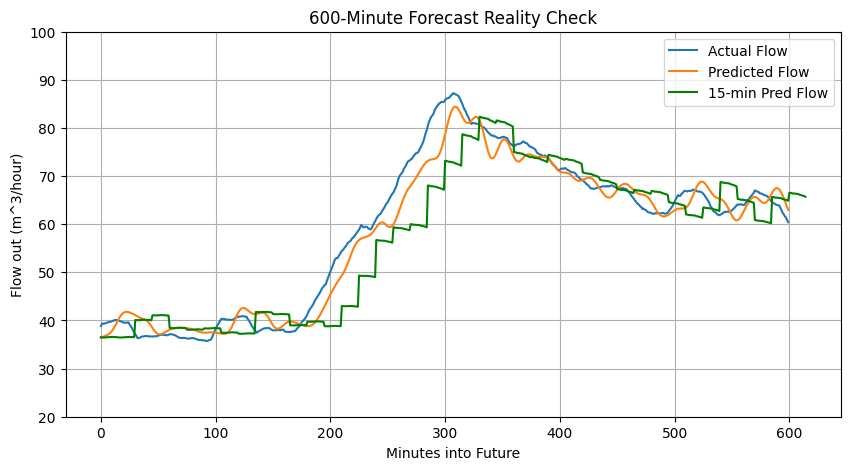

In [ ]:
sample_idx0 = 1440 * 0
interval = 60*10 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval

y_test_flattened = y_test_original[:,0].flatten()
y_test_plot = y_test_flattened[sample_idx0 : sample_idx1]

y_pred_flattened = y_pred_original[:,0].flatten()
y_pred_plot = y_pred_flattened[sample_idx0 : sample_idx1]

#Windows
y_pred2_plot = y_pred_original[0]
for i in range(interval//forecast_size):
    y_pred2_plot = np.concatenate((y_pred2_plot,y_pred_original[i*forecast_size]))

plt.figure(figsize=(10, 5))

plt.plot(range(len(y_test_plot)), y_test_plot, label='Actual Flow')#, marker='o')
plt.plot(range(len(y_pred_plot)), y_pred_plot, label='Predicted Flow')#, marker='x')
plt.plot(range(len(y_pred2_plot)), y_pred2_plot, label=f'{forecast_size}-min Pred Flow', color='green')


plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**Data Export**
- 이 밑으로는 무시

In [ ]:
y_pred_export = np.concatenate( (y_pred_flattened, y_pred_original[-1]))

g_resv_flow_export = g_resv_flow_temp[-1440:]

y_accuracy = (1-np.abs(y_pred_original - y_test_original) / (y_test_original+1))
y_accuracy_export = np.concatenate((y_accuracy[:,0], y_accuracy[-1]))

In [ ]:
del g_resv_flow_export['savgol_smooth']
del g_resv_flow_export['normalized_flow']
del g_resv_flow_export['g_resv_flow']
g_resv_flow_export['g_resv_flow_pred'] = y_pred_export
g_resv_flow_export['accuracy'] = y_accuracy_export

C:\Users\user\AppData\Local\Temp\ipykernel_23392\4057725202.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_resv_flow_export['g_resv_flow_pred'] = y_pred_export
C:\Users\user\AppData\Local\Temp\ipykernel_23392\4057725202.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_resv_flow_export['accuracy'] = y_accuracy_export


In [ ]:
type(g_resv_flow_export)
g_resv_flow_export[:2]

,time,g_resv_flow_pred,accuracy
7198,2023-01-06 00:05:00,29.625864,0.936294
7199,2023-01-06 00:06:00,29.612738,0.936816


In [ ]:
import json

# 1. Convert the DataFrame rows to a list of dictionaries
json_data = g_resv_flow_export.to_json(orient='records', date_format='iso')

# 2. Parse that string back to a Python object and wrap it
# (This step is necessary if you want the 'predictions' header)
final_dict = {
    "predictions": json.loads(json_data)
}

# 3. Convert the final dictionary to a JSON string for Redis
json_for_redis = json.dumps(final_dict)

In [ ]:
json_for_redis

'{"predictions": [{"time": "2023-01-06T00:05:00.000", "g_resv_flow_pred": 29.6258640289, "accuracy": 0.9362937212}, {"time": "2023-01-06T00:06:00.000", "g_resv_flow_pred": 29.6127376556, "accuracy": 0.9368162751}, {"time": "2023-01-06T00:07:00.000", "g_resv_flow_pred": 29.6092662811, "accuracy": 0.93671}, {"time": "2023-01-06T00:08:00.000", "g_resv_flow_pred": 29.6131000519, "accuracy": 0.9396099448}, {"time": "2023-01-06T00:09:00.000", "g_resv_flow_pred": 29.6223621368, "accuracy": 0.9408257604}, {"time": "2023-01-06T00:10:00.000", "g_resv_flow_pred": 29.633928299, "accuracy": 0.9430503845}, {"time": "2023-01-06T00:11:00.000", "g_resv_flow_pred": 29.645647049, "accuracy": 0.9443489909}, {"time": "2023-01-06T00:12:00.000", "g_resv_flow_pred": 29.6554679871, "accuracy": 0.942777276}, {"time": "2023-01-06T00:13:00.000", "g_resv_flow_pred": 29.6622505188, "accuracy": 0.9420512915}, {"time": "2023-01-06T00:14:00.000", "g_resv_flow_pred": 29.6669597626, "accuracy": 0.9394029379}, {"time": "

In [ ]:
json_time = g_resv_flow_export['time'].iloc[0].strftime("%Y-%m-%d")

print(json_time)

2023-01-06


In [ ]:
x=(1,2)
x[0]

1

In [ ]:
from redis import Redis

try:
    r = Redis(host='10.125.121.184', port=6379)
    print("연결 시도 중...")
    if r.ping():
        print("연결 성공! (PONG)")
except Exception as e:
    print(f"연결 실패: {e}")

연결 시도 중...
연결 성공! (PONG)
